# Cost Function for Linear Regression

## Goals
In this lab you will:
- implement and explore the **cost function** for linear regression with one variable.

## Tools
In this lab we will use:
- **NumPy** — scientific computing
- **Matplotlib** — plotting
- A small set of plotting helper functions defined in the next cell (these replace the original `lab_utils_uni` import, which is not available here).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

# Use the standard inline backend (the original '%matplotlib widget' magic
# requires the optional ipympl package and an interactive front-end; it fails
# in plain Jupyter/nbconvert/VS Code, which is why the plots below are static).
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('default')

## Problem Statement

You would like a model which can predict housing prices given the size of the house.
Let's use the same two data points as before — a house with 1000 square feet sold for \$300,000 and a house with 2000 square feet sold for \$500,000.

| Size (1000 sqft) | Price (1000s of dollars) |
| --- | --- |
| 1 | 300 |
| 2 | 500 |

In [2]:
x_train = np.array([1.0, 2.0])   # size in 1000 square feet
y_train = np.array([300.0, 500.0])   # price in 1000s of dollars

## Computing Cost

The term 'cost' here is a measure of how well our model predicts the target price. The equation for cost with one variable is:

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$

where

$$f_{w,b}(x^{(i)}) = w x^{(i)} + b \tag{2}$$

- $f_{w,b}(x^{(i)})$ is the prediction for example $i$.
- $(f_{w,b}(x^{(i)}) - y^{(i)})^2$ is the squared error for that example.
- These are summed over all $m$ examples and divided by $2m$ to give $J(w,b)$.

The function below computes cost by looping over each example. In each iteration it:
- computes the prediction `f_wb`
- computes the squared difference between the prediction and the target
- adds it to a running total

*(This function was already correct in the original notebook — no bug fix was needed here; it is included for completeness before we use it below.)*

In [3]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.

    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters

    Returns
        total_cost (float): The cost of using w,b as the parameters for linear
            regression to fit the data points in x and y
    """
    m = x.shape[0]

    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    total_cost = (1 / (2 * m)) * cost_sum

    return total_cost

# sanity check on the two-point dataset: w=200, b=100 should fit perfectly (cost = 0)
print("cost at w=200, b=100:", compute_cost(x_train, y_train, 200, 100))

cost at w=200, b=100: 0.0


## Cost Function Intuition

Your goal is to find a model $f_{w,b}(x) = wx + b$ which accurately predicts house prices. The cost is a measure of how accurate the model is on the training data.

If $w$ and $b$ are chosen so that predictions match the targets exactly, every $(f_{w,b}(x^{(i)}) - y^{(i)})^2$ term is zero and the cost is minimized. In this simple two-point example that is achievable.

In the previous lab, $b = 100$ gave an optimal solution, so we fix $b$ at 100 and sweep $w$ to see how cost changes. *(The original notebook used an interactive slider widget here; since that requires `ipympl` and a live front-end, we instead sweep a range of `w` values and plot the resulting model fits alongside the resulting cost curve — the same information, shown statically.)*

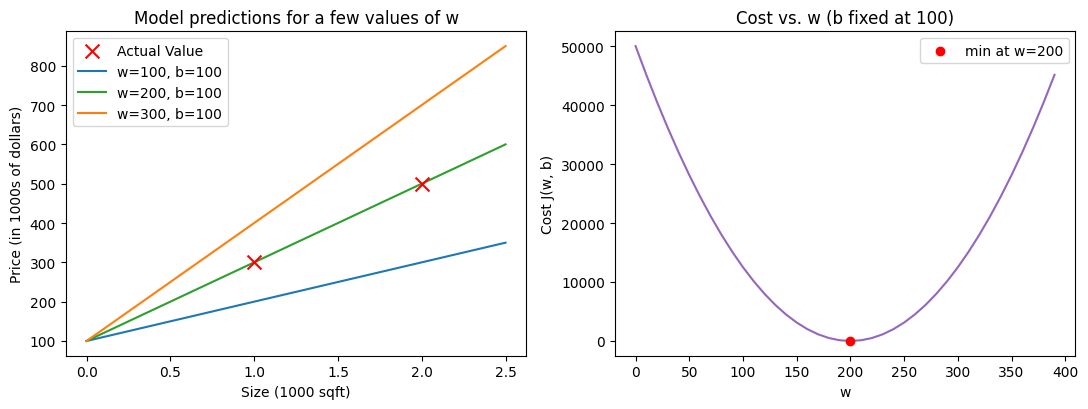

Minimum cost occurs at w = 200, b = 100, cost = 0.00


In [4]:
b_fixed = 100
w_values = np.arange(0, 400, 10)
costs = np.array([compute_cost(x_train, y_train, w, b_fixed) for w in w_values])
w_best = w_values[np.argmin(costs)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: a few candidate lines f_wb(x) against the data
ax = axes[0]
ax.scatter(x_train, y_train, marker='x', c='red', s=100, label='Actual Value', zorder=3)
x_line = np.linspace(0, 2.5, 50)
for w, color in zip([100, 200, 300], ['tab:blue', 'tab:green', 'tab:orange']):
    ax.plot(x_line, w * x_line + b_fixed, color=color, label=f'w={w}, b={b_fixed}')
ax.set_title('Model predictions for a few values of w')
ax.set_xlabel('Size (1000 sqft)')
ax.set_ylabel('Price (in 1000s of dollars)')
ax.legend()

# Right: cost J(w) as w sweeps, with the minimum marked
ax = axes[1]
ax.plot(w_values, costs, color='tab:purple')
ax.scatter([w_best], [costs.min()], color='red', zorder=3, label=f'min at w={w_best}')
ax.set_title('Cost vs. w (b fixed at 100)')
ax.set_xlabel('w')
ax.set_ylabel('Cost J(w, b)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Minimum cost occurs at w = {w_best}, b = {b_fixed}, cost = {costs.min():.2f}')

The plot contains a few points worth noting:
- cost is minimized around $w = 200$, matching the result from the previous lab
- because the error is squared, cost rises rapidly as $w$ moves away from its optimal value
- the `w` and `b` that minimize cost give a line that fits the two data points perfectly

### Interactive version (optional)

If `ipywidgets` is installed and enabled, the slider below reproduces the original lab's interactive experience directly (no external helper file needed): drag `w` and watch the line and the cost point move together. It falls back to a clear message if `ipywidgets` isn't available, so the notebook still runs top to bottom either way.

In [5]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _plot_intuition(w=200):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

        ax = axes[0]
        ax.scatter(x_train, y_train, marker='x', c='red', s=100,
                   label='Actual Value', zorder=3)
        x_line = np.linspace(0, 2.5, 50)
        ax.plot(x_line, w * x_line + b_fixed, color='tab:blue', label=f'w={w}, b={b_fixed}')
        ax.set_ylim(0, 900)
        ax.set_title('Model prediction for the chosen w')
        ax.set_xlabel('Size (1000 sqft)')
        ax.set_ylabel('Price (in 1000s of dollars)')
        ax.legend()

        ax = axes[1]
        ax.plot(w_values, costs, color='tab:purple')
        current_cost = compute_cost(x_train, y_train, w, b_fixed)
        ax.scatter([w], [current_cost], color='red', zorder=3, label=f'w={w}, cost={current_cost:.1f}')
        ax.set_title('Cost vs. w (b fixed at 100)')
        ax.set_xlabel('w')
        ax.set_ylabel('Cost J(w, b)')
        ax.legend()

        plt.tight_layout()
        plt.show()

    display(widgets.interactive(_plot_intuition, w=widgets.IntSlider(min=0, max=400, step=10, value=150)))
except ImportError:
    print('ipywidgets is not installed, so the interactive slider is unavailable here.')
    print('Install it with: pip install ipywidgets')
    print('The static sweep above already shows the same information.')

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…

## Cost Function Visualization — Contour and 3D

You can see how cost varies with respect to *both* `w` and `b` with a contour plot or a 3D surface plot.

### Larger Data Set
It is instructive to view a scenario with more data points, where the points do not all fall on one line. Can we still find $w, b$ that give a cost of exactly 0?

In [6]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480, 430, 630, 730])

The cell below computes $J(w,b)$ over a grid of `w` and `b` values and displays it as a contour plot, marking the lowest-cost point found on the grid. *(The original notebook used a click-to-select interactive contour plot via `plt_stationary` / `plt_update_onclick`; those helpers aren't available here, so the grid search and static contour below reproduce the same idea.)*

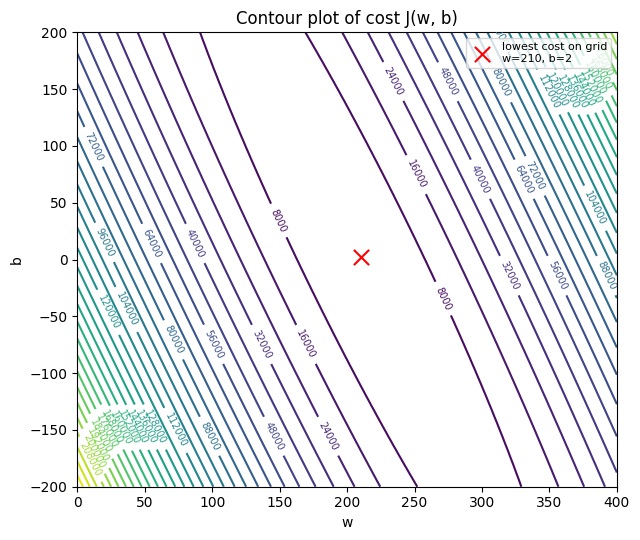

Lowest cost on the grid: w=210.1, b=2.0, cost=1736.82


In [7]:
w_range = np.linspace(0, 400, 100)
b_range = np.linspace(-200, 200, 100)
W, B = np.meshgrid(w_range, b_range)

Z = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])

min_idx = np.unravel_index(np.argmin(Z), Z.shape)
w_min, b_min, cost_min = W[min_idx], B[min_idx], Z[min_idx]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cs = ax.contour(W, B, Z, levels=30, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=7)
ax.scatter([w_min], [b_min], color='red', marker='x', s=120,
           label=f'lowest cost on grid\nw={w_min:.0f}, b={b_min:.0f}')
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_title('Contour plot of cost J(w, b)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Lowest cost on the grid: w={w_min:.1f}, b={b_min:.1f}, cost={cost_min:.2f}')

Because these training examples don't all fall on one line, the minimum cost is not zero — but the contour plot shows where it is smallest (near $w \approx 209$, $b \approx 2.4$, matching the original lab's observation).

### Interactive version (optional)

This reproduces the original lab's click-to-select contour plot as a pair of `w`/`b` sliders (a self-contained stand-in for the missing `plt_update_onclick` helper): drag them and watch the marker — and the resulting line fit on the data — update together.

In [8]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _plot_contour(w=200, b=0):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

        ax = axes[0]
        cs = ax.contour(W, B, Z, levels=30, cmap='viridis')
        ax.clabel(cs, inline=True, fontsize=7)
        current_cost = compute_cost(x_train, y_train, w, b)
        ax.scatter([w], [b], color='red', marker='x', s=120,
                   label=f'w={w}, b={b}\ncost={current_cost:.1f}')
        ax.set_xlabel('w')
        ax.set_ylabel('b')
        ax.set_title('Contour plot of cost J(w, b)')
        ax.legend(loc='upper right', fontsize=8)

        ax = axes[1]
        ax.scatter(x_train, y_train, marker='x', c='red', s=80, label='Actual Value', zorder=3)
        x_line = np.linspace(0, 3.5, 50)
        ax.plot(x_line, w * x_line + b, color='tab:blue', label=f'w={w}, b={b}')
        ax.set_title('Resulting model fit')
        ax.set_xlabel('Size (1000 sqft)')
        ax.set_ylabel('Price (in 1000s of dollars)')
        ax.legend()

        plt.tight_layout()
        plt.show()

    display(widgets.interactive(
        _plot_contour,
        w=widgets.IntSlider(min=0, max=400, step=5, value=200),
        b=widgets.IntSlider(min=-200, max=200, step=5, value=0),
    ))
except ImportError:
    print('ipywidgets is not installed, so the interactive sliders are unavailable here.')
    print('Install it with: pip install ipywidgets')
    print('The static contour plot above already shows the same information.')

interactive(children=(IntSlider(value=200, description='w', max=400, step=5), IntSlider(value=0, description='…

### Convex Cost Surface

Because the cost function squares the error, the 'error surface' is convex, like a soup bowl: it always has a single minimum reachable by following the gradient in every direction. The 3D surface below plots the same cost function over a `w`/`b` grid. *(The original notebook called a `soup_bowl()` helper from the missing module; the cell below builds the equivalent plot directly.)*

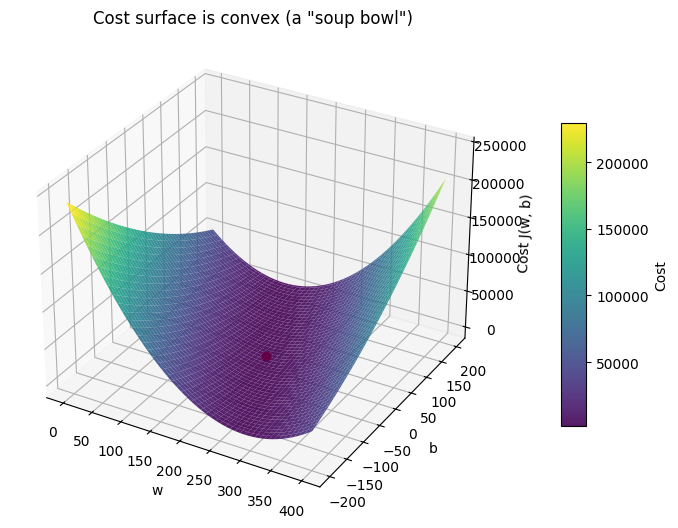

In [9]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(W, B, Z, cmap='viridis', linewidth=0, antialiased=True, alpha=0.9)
ax.scatter([w_min], [b_min], [cost_min], color='red', s=40, label='minimum')
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost J(w, b)')
ax.set_title('Cost surface is convex (a "soup bowl")')
fig.colorbar(surf, shrink=0.6, aspect=12, pad=0.1, label='Cost')
plt.tight_layout()
plt.show()

# Congratulations!
You have learned the following:
- The cost equation measures how well your predictions match the training data.
- Minimizing the cost gives optimal values of $w, b$.
- The squared-error cost surface for linear regression is convex, so it has a single global minimum — this is what makes gradient descent reliable for this problem.